Saving messy_dataset.csv to messy_dataset (1).csv


/tmp/ipykernel_2707/877701725.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  _df['Age'].fillna(_df['Age'].median(), inplace=True)
/tmp/ipykernel_2707/877701725.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

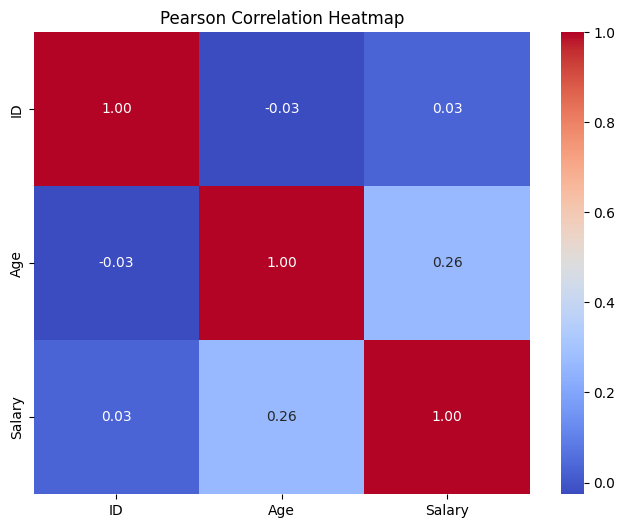

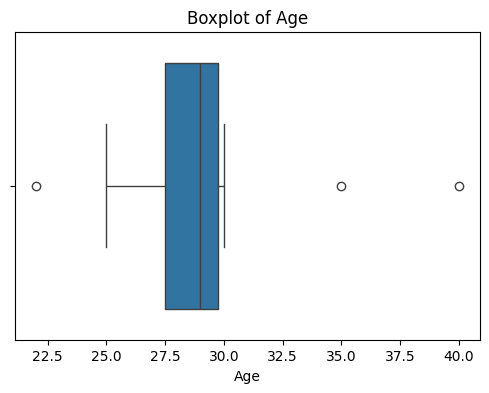

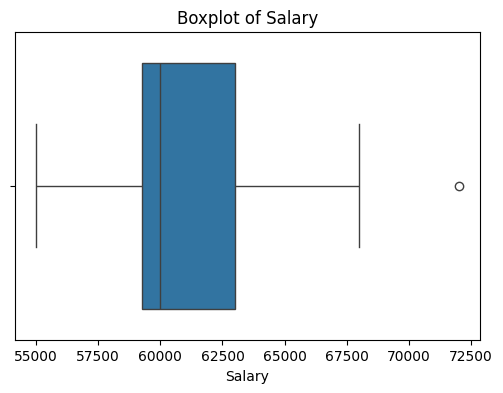

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
from google.colab import files
files.upload()
file_path = 'messy_dataset.csv'
_df = pd.read_csv(file_path)

# Remove duplicates
_df = _df.drop_duplicates()

# Convert data types
_df['Age'] = pd.to_numeric(_df['Age'], errors='coerce')
_df['Salary'] = pd.to_numeric(_df['Salary'], errors='coerce')
_df['Join Date'] = pd.to_datetime(_df['Join Date'], dayfirst=True, errors='coerce')

# Handle missing values
_df['Age'].fillna(_df['Age'].median(), inplace=True)
_df['Salary'].fillna(_df['Salary'].median(), inplace=True)

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(_df[['ID','Age','Salary']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Heatmap')
plt.show()

# Boxplots for outlier detection
for col in ['Age', 'Salary']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=_df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()